In [11]:
import numpy as np
import pandas as pd
import geopandas as gpd
import joblib
import os
from datetime import datetime, timedelta
import re
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

class ModelApplicator2019:
    def __init__(self, model_path, encoder_path, data_2019_path, shapefile_path, output_dir="Predictions_2019"):
        """
        Initialize Model Applicator for 2019 data
        
        Args:
            model_path (str): Path to saved model pipeline
            encoder_path (str): Path to saved label encoder  
            data_2019_path (str): Path to 2019 CSV data
            shapefile_path (str): Path to shapefile for geometry repair
            output_dir (str): Directory to save results
        """
        self.model_path = model_path
        self.encoder_path = encoder_path
        self.data_2019_path = data_2019_path
        self.shapefile_path = shapefile_path
        self.output_dir = output_dir
        os.makedirs(self.output_dir, exist_ok=True)
        
        # Model components
        self.model_pipeline = None
        self.label_encoder = None
        self.training_features = None
        
        # Data
        self.data_2019 = None
        self.shapefile_gdf = None
        self.matched_data = None
        self.predictions = None
        
        # Feature matching info
        self.feature_mapping = {}
        self.missing_features = []
        self.date_substitutions = {}
        self.training_feature_analysis = {}
        
    def load_model_and_extract_training_features(self):
        """Load model and extract the exact training features"""
        print("🔄 Loading trained model and extracting training features...")
        print("="*70)
        
        try:
            # Load model pipeline
            self.model_pipeline = joblib.load(self.model_path)
            print(f"✅ Model loaded from: {self.model_path}")
            
            # Load label encoder
            self.label_encoder = joblib.load(self.encoder_path)
            print(f"✅ Label encoder loaded from: {self.encoder_path}")
            print(f"✅ Available classes: {list(self.label_encoder.classes_)}")
            
            # Extract training features from the model pipeline
            training_features = None
            
            # Method 1: Try to get from feature selector
            if 'feature_selection' in self.model_pipeline.named_steps:
                feature_selector = self.model_pipeline.named_steps['feature_selection']
                if hasattr(feature_selector, 'feature_names_in_'):
                    training_features = feature_selector.feature_names_in_
                    print(f"✅ Found {len(training_features)} training features from feature selector")
            
            # Method 2: Try to get from scaler
            if training_features is None and 'scaler' in self.model_pipeline.named_steps:
                scaler = self.model_pipeline.named_steps['scaler']
                if hasattr(scaler, 'feature_names_in_'):
                    training_features = scaler.feature_names_in_
                    print(f"✅ Found {len(training_features)} training features from scaler")
            
            # Method 3: Try to get from classifier
            if training_features is None and 'classifier' in self.model_pipeline.named_steps:
                classifier = self.model_pipeline.named_steps['classifier']
                if hasattr(classifier, 'feature_names_in_'):
                    training_features = classifier.feature_names_in_
                    print(f"✅ Found {len(training_features)} training features from classifier")
            
            if training_features is None:
                raise ValueError("❌ Could not extract training features from the model!")
                
            self.training_features = list(training_features)
            
            # Analyze training features
            self._analyze_training_features()
            
        except Exception as e:
            print(f"❌ Error loading model: {str(e)}")
            raise
            
        return self
    
    def _analyze_training_features(self):
        """Analyze the training features to understand their structure"""
        print(f"\n🔍 ANALYZING TRAINING FEATURES ({len(self.training_features)} total):")
        print("="*70)
        
        # Categorize features
        date_features = {}
        static_features = []
        band_features = {}
        index_features = {}
        
        # Updated patterns to match both formats
        date_pattern_with_hyphens = r'(\w+)_(\d{4}-\d{2}-\d{2})'  # e.g., NDVI_2024-04-04
        date_pattern_no_hyphens = r'(\w+)_(\d{8})'  # e.g., B6_20240426
        
        for feature in self.training_features:
            # Try pattern with hyphens first
            match = re.search(date_pattern_with_hyphens, feature)
            if match:
                base_name = match.group(1)
                date_str = match.group(2)
            else:
                # Try pattern without hyphens
                match = re.search(date_pattern_no_hyphens, feature)
                if match:
                    base_name = match.group(1)
                    date_str_raw = match.group(2)
                    # Convert YYYYMMDD to YYYY-MM-DD
                    date_str = f"{date_str_raw[:4]}-{date_str_raw[4:6]}-{date_str_raw[6:8]}"
                else:
                    match = None
            
            if match:
                if base_name not in date_features:
                    date_features[base_name] = []
                date_features[base_name].append((feature, date_str))
                
                # Categorize by type
                if base_name.startswith('B') and base_name[1:].isdigit():
                    if base_name not in band_features:
                        band_features[base_name] = []
                    band_features[base_name].append((feature, date_str))
                elif base_name in ['NDVI', 'NDWI', 'NDMI', 'EVI', 'SAVI', 'GNDVI', 'NBR', 'NBR2', '2BDA', 'NDCI', 'ENDVI', 'NDRE', 'GRVI', 'MSAVI', 'LSWI', 'MNDWI', 'MBI', 'EMBI', 'MCARI2', 'TDVI']:
                    if base_name not in index_features:
                        index_features[base_name] = []
                    index_features[base_name].append((feature, date_str))
            else:
                static_features.append(feature)
        
        # Sort dates for each feature type
        for base_name in date_features:
            date_features[base_name].sort(key=lambda x: x[1])
        
        self.training_feature_analysis = {
            'date_features': date_features,
            'static_features': static_features,
            'band_features': band_features,
            'index_features': index_features
        }
        
        print(f"📊 TRAINING FEATURE BREAKDOWN:")
        print(f"   📅 Date-based features: {len(date_features)} categories")
        print(f"   🔢 Static features: {len(static_features)}")
        print(f"   🌐 Band features: {len(band_features)} bands")
        print(f"   📈 Index features: {len(index_features)} indices")
        
        if band_features:
            print(f"\n🌐 SPECTRAL BANDS IN TRAINING:")
            for band, dates in band_features.items():
                print(f"   {band}: {len(dates)} dates ({dates[0][1]} to {dates[-1][1]})")
        
        if index_features:
            print(f"\n📈 VEGETATION INDICES IN TRAINING:")
            for idx, dates in index_features.items():
                print(f"   {idx}: {len(dates)} dates ({dates[0][1]} to {dates[-1][1]})")
        
        if static_features:
            print(f"\n🔢 STATIC FEATURES IN TRAINING:")
            for feature in static_features[:10]:  # Show first 10
                print(f"   {feature}")
            if len(static_features) > 10:
                print(f"   ... and {len(static_features)-10} more")
    
    def load_2019_data(self):
        """Load 2019 data and analyze available features"""
        print("\n🔄 Loading and analyzing 2019 data...")
        print("="*50)
        
        try:
            self.data_2019 = pd.read_csv(self.data_2019_path)
            print(f"✅ 2019 data loaded: {self.data_2019.shape}")
            
            # Show available columns
            print(f"📊 Available columns: {len(self.data_2019.columns)}")
            
            # Identify feature columns (exclude geometry and ID columns)
            exclude_cols = ['geometry', 'label', 'layer', 'PXLVAL', 'Unnamed: 0']
            feature_cols = [col for col in self.data_2019.columns 
                          if col not in exclude_cols and pd.api.types.is_numeric_dtype(self.data_2019[col])]
            
            print(f"🔧 Numeric feature columns: {len(feature_cols)}")
            
            # Analyze 2019 date-based features
            available_date_features = self._analyze_2019_date_features(feature_cols)
            print(f"📅 Date-based feature categories in 2019: {len(available_date_features)}")
            
            # Show detailed breakdown
            print(f"\n📊 DETAILED 2019 FEATURE ANALYSIS:")
            for base_name, dates in available_date_features.items():
                print(f"   {base_name}: {len(dates)} dates ({dates[0][1]} to {dates[-1][1]})")
            
            return feature_cols, available_date_features
            
        except Exception as e:
            print(f"❌ Error loading 2019 data: {str(e)}")
            raise
    
    def _analyze_2019_date_features(self, feature_cols):
        """Analyze and categorize 2019 date-based features"""
        date_features = {}
        
        # Updated patterns to match both formats
        date_pattern_with_hyphens = r'(\w+)_(\d{4}-\d{2}-\d{2})'  # e.g., NDVI_2019-05-15
        date_pattern_no_hyphens = r'(\w+)_(\d{8})'  # e.g., B6_20190515
        
        for col in feature_cols:
            # Try pattern with hyphens first
            match = re.search(date_pattern_with_hyphens, col)
            if match:
                base_name = match.group(1)
                date_str = match.group(2)
            else:
                # Try pattern without hyphens
                match = re.search(date_pattern_no_hyphens, col)
                if match:
                    base_name = match.group(1)
                    date_str_raw = match.group(2)
                    # Convert YYYYMMDD to YYYY-MM-DD
                    date_str = f"{date_str_raw[:4]}-{date_str_raw[4:6]}-{date_str_raw[6:8]}"
                else:
                    match = None
            
            if match:
                if base_name not in date_features:
                    date_features[base_name] = []
                date_features[base_name].append((col, date_str))
        
        # Sort dates for each feature
        for base_name in date_features:
            date_features[base_name].sort(key=lambda x: x[1])
        
        return date_features
    
    def load_shapefile_for_geometry_repair(self):
        """Load shapefile for geometry repair"""
        print("\n🔄 Loading shapefile for geometry repair...")
        print("="*50)
        
        try:
            self.shapefile_gdf = gpd.read_file(self.shapefile_path)
            print(f"✅ Shapefile loaded: {self.shapefile_gdf.shape}")
            print(f"📊 Shapefile columns: {len(self.shapefile_gdf.columns)} total")
            
            # Check if PXLVAL column exists
            if 'PXLVAL' not in self.shapefile_gdf.columns:
                print("❌ PXLVAL column not found in shapefile!")
                available_cols = [col for col in self.shapefile_gdf.columns 
                                if 'val' in col.lower() or 'id' in col.lower() or 'pxl' in col.lower()]
                print(f"💡 Possible ID columns: {available_cols}")
            else:
                print(f"✅ PXLVAL column found with {len(self.shapefile_gdf['PXLVAL'].unique())} unique values")
                
            return self
            
        except Exception as e:
            print(f"❌ Error loading shapefile: {str(e)}")
            raise
    
    def match_training_features_with_2019(self, available_2019_features):
        """
        Match each training feature with available 2019 features
        Handle seasonal date substitutions for missing exact dates
        """
        print(f"\n🔄 MATCHING TRAINING FEATURES WITH 2019 DATA")
        print("="*80)
        
        self.feature_mapping = {}
        self.date_substitutions = {}
        self.missing_features = []
        
        # Get training feature analysis
        training_date_features = self.training_feature_analysis['date_features']
        training_static_features = self.training_feature_analysis['static_features']
        
        print(f"🎯 Need to match {len(self.training_features)} training features")
        print(f"📊 Available 2019 features: {len(available_2019_features)}")
        
        # Track matching statistics
        exact_matches = 0
        date_substitutions = 0
        filled_with_zeros = 0
        
        print(f"\n🔍 FEATURE MATCHING PROCESS:")
        print("-" * 60)
        
        for training_feature in self.training_features:
            # Check for exact match first
            if training_feature in available_2019_features:
                self.feature_mapping[training_feature] = training_feature
                exact_matches += 1
                print(f"✅ EXACT: {training_feature}")
                continue
            
            # Check if it's a date-based feature that needs substitution
            matched_feature = self._find_seasonal_match(training_feature, available_2019_features)
            
            if matched_feature:
                # Extract details for reporting
                base_name, target_date, closest_feature, closest_date, days_diff = matched_feature
                
                self.feature_mapping[training_feature] = closest_feature
                self.date_substitutions[training_feature] = {
                    'base_name': base_name,
                    'target_date': target_date,
                    'actual_date': closest_date,
                    'actual_feature': closest_feature,
                    'days_difference': days_diff
                }
                date_substitutions += 1
                print(f"🔄 SEASONAL: {training_feature} → {closest_feature} (±{days_diff} days)")
            else:
                self.missing_features.append(training_feature)
                filled_with_zeros += 1
                print(f"❌ MISSING: {training_feature} (will fill with zeros)")
        
        print(f"\n📊 MATCHING SUMMARY:")
        print(f"   ✅ Exact matches: {exact_matches}")
        print(f"   🔄 Seasonal substitutions: {date_substitutions}")
        print(f"   ❌ Missing (filled with zeros): {filled_with_zeros}")
        print(f"   📈 Total features: {len(self.training_features)}")
        
        # Show detailed date substitution info
        if self.date_substitutions:
            print(f"\n📅 DETAILED SEASONAL SUBSTITUTIONS:")
            print("-" * 50)
            for train_feature, sub_info in self.date_substitutions.items():
                print(f"   {sub_info['base_name']}: {sub_info['target_date']} → {sub_info['actual_date']} ({sub_info['days_difference']:+d} days)")
        
        # Group missing features by type
        if self.missing_features:
            missing_by_type = {}
            for missing in self.missing_features:
                # Try both date patterns
                date_pattern_with_hyphens = r'(\w+)_(\d{4}-\d{2}-\d{2})'
                date_pattern_no_hyphens = r'(\w+)_(\d{8})'
                
                match = re.search(date_pattern_with_hyphens, missing)
                if not match:
                    match = re.search(date_pattern_no_hyphens, missing)
                
                if match:
                    base_name = match.group(1)
                    if base_name not in missing_by_type:
                        missing_by_type[base_name] = 0
                    missing_by_type[base_name] += 1
                else:
                    if 'static' not in missing_by_type:
                        missing_by_type['static'] = 0
                    missing_by_type['static'] += 1
            
            print(f"\n⚠️  MISSING FEATURES BY TYPE:")
            print("-" * 40)
            for feature_type, count in missing_by_type.items():
                print(f"   {feature_type}: {count} features")
        
        return exact_matches, date_substitutions, filled_with_zeros
    
    def _find_seasonal_match(self, training_feature, available_2019_features):
        """
        Find the best seasonal match for a training feature in 2019 data
        For a training feature like NDVI_2024-04-04, look for closest to April 4th in 2019
        """
        # Try both date patterns
        date_pattern_with_hyphens = r'(\w+)_(\d{4}-\d{2}-\d{2})'
        date_pattern_no_hyphens = r'(\w+)_(\d{8})'
        
        # First try with hyphens
        match = re.search(date_pattern_with_hyphens, training_feature)
        if match:
            base_name = match.group(1)
            target_date_str = match.group(2)
        else:
            # Try without hyphens
            match = re.search(date_pattern_no_hyphens, training_feature)
            if match:
                base_name = match.group(1)
                date_str_raw = match.group(2)
                # Convert YYYYMMDD to YYYY-MM-DD
                target_date_str = f"{date_str_raw[:4]}-{date_str_raw[4:6]}-{date_str_raw[6:8]}"
            else:
                # Not a date-based feature
                return None
        
        try:
            target_date = datetime.strptime(target_date_str, "%Y-%m-%d")
        except ValueError:
            return None
        
        # Extract month and day for seasonal matching
        target_month_day = (target_date.month, target_date.day)
        
        # Find all 2019 features with this base name
        candidate_features = []
        
        for feature in available_2019_features:
            # Try both patterns for 2019 features
            match_2019 = re.search(date_pattern_with_hyphens, feature)
            if match_2019:
                if match_2019.group(1) == base_name:
                    feature_date_str = match_2019.group(2)
                else:
                    continue
            else:
                match_2019 = re.search(date_pattern_no_hyphens, feature)
                if match_2019 and match_2019.group(1) == base_name:
                    date_str_raw = match_2019.group(2)
                    feature_date_str = f"{date_str_raw[:4]}-{date_str_raw[4:6]}-{date_str_raw[6:8]}"
                else:
                    continue
            
            try:
                feature_date = datetime.strptime(feature_date_str, "%Y-%m-%d")
                
                # Calculate seasonal distance (considering year wraparound)
                feature_month_day = (feature_date.month, feature_date.day)
                
                # Calculate days difference within the year (ignoring year)
                # Create dates in the same year for comparison
                same_year_target = datetime(2019, target_date.month, target_date.day)
                same_year_feature = datetime(2019, feature_date.month, feature_date.day)
                
                days_diff = (same_year_feature - same_year_target).days
                
                # Handle year wraparound (e.g., Dec to Jan)
                if abs(days_diff) > 180:  # More than half a year
                    if days_diff > 0:
                        days_diff = days_diff - 365
                    else:
                        days_diff = days_diff + 365
                
                candidate_features.append((feature, feature_date_str, abs(days_diff), days_diff))
                
            except ValueError:
                continue
        
        if not candidate_features:
            return None
        
        # Sort by absolute difference and get the closest
        candidate_features.sort(key=lambda x: x[2])
        closest_feature, closest_date, abs_diff, signed_diff = candidate_features[0]
        
        return (base_name, target_date_str, closest_feature, closest_date, signed_diff)
    
    def prepare_feature_matrix(self):
        """Prepare feature matrix with exact training feature names and order"""
        print("\n🔄 Preparing feature matrix with training feature structure...")
        print("="*70)
        
        # Create DataFrame with exact training features in correct order
        feature_data = {}
        
        for training_feature in self.training_features:
            if training_feature in self.feature_mapping:
                # Map to 2019 feature
                mapped_feature = self.feature_mapping[training_feature]
                if mapped_feature in self.data_2019.columns:
                    feature_data[training_feature] = self.data_2019[mapped_feature].values
                else:
                    print(f"⚠️  {mapped_feature} not found in 2019 data, filling with zeros")
                    feature_data[training_feature] = np.zeros(len(self.data_2019))
            else:
                # Missing feature - fill with zeros
                feature_data[training_feature] = np.zeros(len(self.data_2019))
        
        # Create DataFrame with exact training feature names and order
        feature_df = pd.DataFrame(feature_data, columns=self.training_features)
        
        print(f"✅ Feature matrix prepared: {feature_df.shape}")
        print(f"📊 Features match training exactly: {list(feature_df.columns) == self.training_features}")
        
        # Handle any remaining NaN values
        feature_df = feature_df.fillna(0)
        
        # Show some statistics
        non_zero_features = (feature_df != 0).any().sum()
        zero_features = len(feature_df.columns) - non_zero_features
        
        print(f"📈 Non-zero features: {non_zero_features}")
        print(f"🔢 Zero-filled features: {zero_features}")
        
        return feature_df
    
    def repair_geometry_using_shapefile(self):
        """Repair damaged geometry using shapefile"""
        print("\n🔄 Repairing geometry using shapefile...")
        print("="*45)
        
        if 'PXLVAL' not in self.data_2019.columns:
            print("❌ PXLVAL column not found in 2019 data!")
            return None
        
        try:
            # Create a mapping from PXLVAL to geometry
            pxlval_to_geometry = dict(zip(self.shapefile_gdf['PXLVAL'], 
                                         self.shapefile_gdf.geometry))
            
            # Map geometries to 2019 data
            repaired_geometries = []
            successful_repairs = 0
            
            for pxlval in self.data_2019['PXLVAL']:
                if pxlval in pxlval_to_geometry:
                    repaired_geometries.append(pxlval_to_geometry[pxlval])
                    successful_repairs += 1
                else:
                    repaired_geometries.append(None)
            
            self.data_2019['repaired_geometry'] = repaired_geometries
            
            print(f"✅ Geometry repair completed!")
            print(f"📊 Successfully repaired: {successful_repairs}/{len(self.data_2019)} geometries")
            print(f"📊 Success rate: {(successful_repairs/len(self.data_2019))*100:.1f}%")
            
            return successful_repairs
            
        except Exception as e:
            print(f"❌ Error in geometry repair: {str(e)}")
            return 0
    
    def make_predictions(self, feature_matrix):
        """Make predictions using the trained model"""
        print("\n🔮 Making predictions with properly formatted features...")
        print("="*65)
        
        try:
            print(f"🔍 Input feature matrix shape: {feature_matrix.shape}")
            print(f"🔍 Feature names match training: {list(feature_matrix.columns) == self.training_features}")
            
            # Make predictions
            y_pred = self.model_pipeline.predict(feature_matrix)
            y_pred_proba = self.model_pipeline.predict_proba(feature_matrix)
            
            # Convert predictions back to original labels
            predicted_labels = self.label_encoder.inverse_transform(y_pred)
            
            print(f"✅ Predictions completed for {len(predicted_labels)} samples")
            
            # Create predictions DataFrame
            predictions_df = self.data_2019.copy()
            predictions_df['predicted_layer'] = predicted_labels
            predictions_df['prediction_confidence'] = np.max(y_pred_proba, axis=1)
            
            # Add probability columns for each class
            class_names = self.label_encoder.classes_
            for i, class_name in enumerate(class_names):
                predictions_df[f'prob_{class_name}'] = y_pred_proba[:, i]
            
            # Show prediction summary
            pred_counts = pd.Series(predicted_labels).value_counts()
            print("\n📊 PREDICTION SUMMARY:")
            print("-" * 40)
            for class_name, count in pred_counts.items():
                percentage = (count / len(predicted_labels)) * 100
                print(f"   {class_name}: {count:,} samples ({percentage:.1f}%)")
            
            # Show confidence statistics
            confidence_stats = {
                'mean': np.mean(predictions_df['prediction_confidence']),
                'min': np.min(predictions_df['prediction_confidence']),
                'max': np.max(predictions_df['prediction_confidence']),
                'std': np.std(predictions_df['prediction_confidence']),
                'q25': np.percentile(predictions_df['prediction_confidence'], 25),
                'q75': np.percentile(predictions_df['prediction_confidence'], 75)
            }
            
            print(f"\n🎯 CONFIDENCE STATISTICS:")
            print("-" * 30)
            print(f"   Mean: {confidence_stats['mean']:.3f}")
            print(f"   Min:  {confidence_stats['min']:.3f}")
            print(f"   Max:  {confidence_stats['max']:.3f}")
            print(f"   Std:  {confidence_stats['std']:.3f}")
            print(f"   Q25:  {confidence_stats['q25']:.3f}")
            print(f"   Q75:  {confidence_stats['q75']:.3f}")
            
            # Confidence ranges
            conf_ranges = [
                ('Very High (>0.9)', (predictions_df['prediction_confidence'] > 0.9).sum()),
                ('High (0.8-0.9)', ((predictions_df['prediction_confidence'] > 0.8) & 
                                   (predictions_df['prediction_confidence'] <= 0.9)).sum()),
                ('Medium (0.6-0.8)', ((predictions_df['prediction_confidence'] > 0.6) & 
                                     (predictions_df['prediction_confidence'] <= 0.8)).sum()),
                ('Low (<0.6)', (predictions_df['prediction_confidence'] <= 0.6).sum())
            ]
            
            print(f"\n📈 CONFIDENCE DISTRIBUTION:")
            print("-" * 35)
            for range_name, count in conf_ranges:
                percentage = (count / len(predictions_df)) * 100
                print(f"   {range_name}: {count:,} samples ({percentage:.1f}%)")
            
            self.predictions = predictions_df
            return predictions_df
            
        except Exception as e:
            print(f"❌ Error making predictions: {str(e)}")
            raise
    
    def save_results(self):
        """Save all results and create comprehensive reports"""
        print("\n💾 Saving results and creating reports...")
        print("="*50)
        
        # Save predictions
        predictions_path = os.path.join(self.output_dir, 'predictions_2019.csv')
        self.predictions.to_csv(predictions_path, index=False)
        print(f"✅ Predictions saved: {predictions_path}")
        
        # Save detailed feature mapping report
        self._save_detailed_feature_mapping_report()
        
        # Create GeoDataFrame if geometry repair was successful
        if 'repaired_geometry' in self.predictions.columns:
            valid_geometry_mask = self.predictions['repaired_geometry'].notna()
            if valid_geometry_mask.sum() > 0:
                gdf = gpd.GeoDataFrame(
                    self.predictions[valid_geometry_mask], 
                    geometry='repaired_geometry'
                )
                
                # Set CRS (assuming WGS84)
                gdf.set_crs('EPSG:4326', inplace=True, allow_override=True)
                
                # Save as shapefile
                shapefile_path = os.path.join(self.output_dir, 'predictions_2019.shp')
                gdf.to_file(shapefile_path)
                print(f"✅ Shapefile saved: {shapefile_path}")
        
        return self.output_dir
    
    def _save_detailed_feature_mapping_report(self):
        """Save detailed feature mapping report"""
        mapping_path = os.path.join(self.output_dir, 'detailed_feature_mapping_report.txt')
        
        with open(mapping_path, 'w') as f:
            f.write("DETAILED FEATURE MAPPING REPORT - 2019 PREDICTIONS\n")
            f.write("=" * 80 + "\n\n")
            f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
            
            f.write(f"SUMMARY STATISTICS:\n")
            f.write("-" * 25 + "\n")
            f.write(f"Total training features: {len(self.training_features)}\n")
            exact_matches = len([f for f, m in self.feature_mapping.items() 
                               if f == m and f in self.data_2019.columns])
            f.write(f"Exact matches: {exact_matches}\n")
            f.write(f"Seasonal substitutions: {len(self.date_substitutions)}\n")
            f.write(f"Missing features: {len(self.missing_features)}\n\n")
            
            f.write("FEATURE MAPPING (Training → 2019):\n")
            f.write("-" * 45 + "\n")
            for training_feature, mapped_feature in self.feature_mapping.items():
                if training_feature in self.date_substitutions:
                    sub_info = self.date_substitutions[training_feature]
                    f.write(f"{training_feature} → {mapped_feature} (±{sub_info['days_difference']} days)\n")
                else:
                    f.write(f"{training_feature} → {mapped_feature} (exact match)\n")
            
            f.write(f"\nSEASONAL SUBSTITUTIONS DETAILS ({len(self.date_substitutions)}):\n")
            f.write("-" * 50 + "\n")
            for training_feature, sub_info in self.date_substitutions.items():
                f.write(f"{sub_info['base_name']}:\n")
                f.write(f"  Training date: {sub_info['target_date']}\n")
                f.write(f"  2019 date: {sub_info['actual_date']}\n")
                f.write(f"  Seasonal difference: {sub_info['days_difference']:+d} days\n")
                f.write(f"  Training feature: {training_feature}\n")
                f.write(f"  2019 feature: {sub_info['actual_feature']}\n\n")
            
            f.write(f"MISSING FEATURES ({len(self.missing_features)}):\n")
            f.write("-" * 35 + "\n")
            for feature in self.missing_features:
                f.write(f"{feature} (filled with zeros)\n")
        
        print(f"✅ Detailed feature mapping report saved: {mapping_path}")
    
    def create_comprehensive_summary_report(self):
        """Create comprehensive summary report"""
        print("\n📄 Creating comprehensive summary report...")
        print("="*50)
        
        report_lines = []
        report_lines.append("=" * 100)
        report_lines.append("COMPREHENSIVE MODEL APPLICATION REPORT - 2019 PREDICTIONS")
        report_lines.append("=" * 100)
        report_lines.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        report_lines.append("")
        
        # Input files section
        report_lines.append("INPUT FILES AND PATHS:")
        report_lines.append("-" * 30)
        report_lines.append(f"Model: {self.model_path}")
        report_lines.append(f"Encoder: {self.encoder_path}")
        report_lines.append(f"2019 Data: {self.data_2019_path}")
        report_lines.append(f"Shapefile: {self.shapefile_path}")
        report_lines.append(f"Output Directory: {self.output_dir}")
        report_lines.append("")
        
        # Model and data information
        report_lines.append("MODEL AND DATA INFORMATION:")
        report_lines.append("-" * 35)
        report_lines.append(f"Available classes: {', '.join(self.label_encoder.classes_)}")
        report_lines.append(f"Number of classes: {len(self.label_encoder.classes_)}")
        report_lines.append(f"Total 2019 samples: {len(self.data_2019):,}")
        report_lines.append(f"2019 data shape: {self.data_2019.shape}")
        report_lines.append("")
        
        # Training features analysis
        report_lines.append("TRAINING MODEL FEATURE ANALYSIS:")
        report_lines.append("-" * 40)
        report_lines.append(f"Total training features: {len(self.training_features)}")
        
        training_analysis = self.training_feature_analysis
        report_lines.append(f"Date-based feature categories: {len(training_analysis['date_features'])}")
        report_lines.append(f"Static features: {len(training_analysis['static_features'])}")
        report_lines.append(f"Band features: {len(training_analysis['band_features'])}")
        report_lines.append(f"Index features: {len(training_analysis['index_features'])}")
        
        if training_analysis['band_features']:
            report_lines.append("\nSpectral Bands in Training Model:")
            for band, dates in training_analysis['band_features'].items():
                report_lines.append(f"  {band}: {len(dates)} dates")
        
        if training_analysis['index_features']:
            report_lines.append("\nVegetation Indices in Training Model:")
            for idx, dates in training_analysis['index_features'].items():
                report_lines.append(f"  {idx}: {len(dates)} dates")
        
        report_lines.append("")
        
        # Feature matching results
        report_lines.append("FEATURE MATCHING RESULTS:")
        report_lines.append("-" * 32)
        exact_matches = len([f for f, m in self.feature_mapping.items() 
                           if f == m and f in self.data_2019.columns])
        
        report_lines.append(f"Exact matches: {exact_matches}")
        report_lines.append(f"Seasonal substitutions: {len(self.date_substitutions)}")
        report_lines.append(f"Missing features (filled with zeros): {len(self.missing_features)}")
        report_lines.append(f"Total features matched: {len(self.feature_mapping)}")
        
        # Date substitutions summary
        if self.date_substitutions:
            report_lines.append(f"\nSeasonal Substitution Summary:")
            date_diffs = [abs(sub['days_difference']) for sub in self.date_substitutions.values()]
            report_lines.append(f"  Average seasonal difference: {np.mean(date_diffs):.1f} days")
            report_lines.append(f"  Maximum seasonal difference: {max(date_diffs)} days")
            report_lines.append(f"  Minimum seasonal difference: {min(date_diffs)} days")
            
            # Group by feature type
            feature_types = {}
            for sub_info in self.date_substitutions.values():
                base_name = sub_info['base_name']
                if base_name not in feature_types:
                    feature_types[base_name] = 0
                feature_types[base_name] += 1
            
            report_lines.append(f"\nSeasonal substitutions by feature type:")
            for feature_type, count in feature_types.items():
                report_lines.append(f"  {feature_type}: {count} substitutions")
        
        report_lines.append("")
        
        # Geometry repair results
        if 'repaired_geometry' in self.data_2019.columns:
            successful_repairs = self.data_2019['repaired_geometry'].notna().sum()
            repair_rate = (successful_repairs / len(self.data_2019)) * 100
            report_lines.append("GEOMETRY REPAIR RESULTS:")
            report_lines.append("-" * 28)
            report_lines.append(f"Successfully repaired: {successful_repairs:,}/{len(self.data_2019):,} geometries")
            report_lines.append(f"Repair success rate: {repair_rate:.1f}%")
            report_lines.append(f"Failed repairs: {len(self.data_2019) - successful_repairs:,}")
            report_lines.append("")
        
        # Prediction results
        if self.predictions is not None:
            pred_counts = self.predictions['predicted_layer'].value_counts()
            report_lines.append("PREDICTION RESULTS BY CLASS:")
            report_lines.append("-" * 35)
            for class_name, count in pred_counts.items():
                percentage = (count / len(self.predictions)) * 100
                report_lines.append(f"{class_name}: {count:,} samples ({percentage:.1f}%)")
            
            report_lines.append("")
            
            # Confidence statistics
            confidence_stats = self.predictions['prediction_confidence']
            report_lines.append("PREDICTION CONFIDENCE STATISTICS:")
            report_lines.append("-" * 40)
            report_lines.append(f"Mean confidence: {confidence_stats.mean():.3f}")
            report_lines.append(f"Median confidence: {confidence_stats.median():.3f}")
            report_lines.append(f"Min confidence: {confidence_stats.min():.3f}")
            report_lines.append(f"Max confidence: {confidence_stats.max():.3f}")
            report_lines.append(f"Standard deviation: {confidence_stats.std():.3f}")
            
            # Confidence distribution
            conf_ranges = [
                ('Very High (>0.9)', (confidence_stats > 0.9).sum()),
                ('High (0.8-0.9)', ((confidence_stats > 0.8) & (confidence_stats <= 0.9)).sum()),
                ('Medium (0.6-0.8)', ((confidence_stats > 0.6) & (confidence_stats <= 0.8)).sum()),
                ('Low (<0.6)', (confidence_stats <= 0.6).sum())
            ]
            
            report_lines.append(f"\nConfidence Distribution:")
            for range_name, count in conf_ranges:
                percentage = (count / len(self.predictions)) * 100
                report_lines.append(f"  {range_name}: {count:,} samples ({percentage:.1f}%)")
        
        report_lines.append("")
        
        # Missing features impact analysis
        if self.missing_features:
            report_lines.append("MISSING FEATURES IMPACT ANALYSIS:")
            report_lines.append("-" * 40)
            report_lines.append(f"Total missing features: {len(self.missing_features)}")
            report_lines.append(f"Percentage of features missing: {(len(self.missing_features)/len(self.training_features))*100:.1f}%")
            
            # Group missing features by type
            missing_by_type = {}
            date_pattern_with_hyphens = r'(\w+)_(\d{4}-\d{2}-\d{2})'
            date_pattern_no_hyphens = r'(\w+)_(\d{8})'
            
            for missing in self.missing_features:
                match = re.search(date_pattern_with_hyphens, missing)
                if not match:
                    match = re.search(date_pattern_no_hyphens, missing)
                
                if match:
                    base_name = match.group(1)
                    if base_name not in missing_by_type:
                        missing_by_type[base_name] = []
                    missing_by_type[base_name].append(missing)
                else:
                    if 'static' not in missing_by_type:
                        missing_by_type['static'] = []
                    missing_by_type['static'].append(missing)
            
            report_lines.append(f"\nMissing features by type:")
            for feature_type, features in missing_by_type.items():
                report_lines.append(f"  {feature_type}: {len(features)} features")
                if len(features) <= 5:  # Show all if 5 or fewer
                    for feature in features:
                        report_lines.append(f"    - {feature}")
                else:  # Show first 3 and indicate more
                    for feature in features[:3]:
                        report_lines.append(f"    - {feature}")
                    report_lines.append(f"    - ... and {len(features)-3} more")
        
        report_lines.append("")
        
        # Output files section
        report_lines.append("OUTPUT FILES GENERATED:")
        report_lines.append("-" * 28)
        report_lines.append("✅ predictions_2019.csv - Main predictions file")
        report_lines.append("✅ detailed_feature_mapping_report.txt - Feature matching details")
        report_lines.append("✅ COMPREHENSIVE_SUMMARY_REPORT.txt - This summary report")
        
        if 'repaired_geometry' in self.data_2019.columns and self.data_2019['repaired_geometry'].notna().sum() > 0:
            report_lines.append("✅ predictions_2019.shp - Shapefile with repaired geometries")
        
        report_lines.append("")
        
        # Recommendations section
        report_lines.append("RECOMMENDATIONS AND NOTES:")
        report_lines.append("-" * 32)
        
        if len(self.missing_features) > len(self.training_features) * 0.2:
            report_lines.append("⚠️  HIGH MISSING FEATURE RATE: More than 20% of training features are missing.")
            report_lines.append("   This may impact prediction accuracy. Consider:")
            report_lines.append("   - Acquiring more complete 2019 data")
            report_lines.append("   - Retraining model with available 2019 features")
        
        if self.date_substitutions:
            avg_days_diff = np.mean([abs(sub['days_difference']) for sub in self.date_substitutions.values()])
            if avg_days_diff > 30:
                report_lines.append("⚠️  LARGE SEASONAL DIFFERENCES: Average seasonal substitution > 30 days.")
                report_lines.append("   Temporal accuracy may be reduced for seasonal features.")
        
        if self.predictions is not None:
            low_conf_rate = (self.predictions['prediction_confidence'] < 0.6).sum() / len(self.predictions)
            if low_conf_rate > 0.3:
                report_lines.append("⚠️  HIGH LOW-CONFIDENCE PREDICTIONS: >30% of predictions have confidence <0.6.")
                report_lines.append("   Consider manual review of low-confidence areas.")
        
        if 'repaired_geometry' in self.data_2019.columns:
            repair_rate = self.data_2019['repaired_geometry'].notna().sum() / len(self.data_2019)
            if repair_rate < 0.9:
                report_lines.append(f"⚠️  GEOMETRY REPAIR: Only {repair_rate*100:.1f}% of geometries successfully repaired.")
                report_lines.append("   Some spatial outputs may be incomplete.")
        
        report_lines.append("")
        report_lines.append("SEASONAL MATCHING EXPLANATION:")
        report_lines.append("-" * 40)
        report_lines.append("For date-based features, seasonal matching was used:")
        report_lines.append("- Training feature NDVI_2024-04-04 → closest to April 4th in 2019")
        report_lines.append("- This preserves seasonal phenological patterns")
        report_lines.append("- Days difference shows temporal offset within the same season")
        report_lines.append("")
        report_lines.append("=" * 100)
        
        # Save report
        report_text = "\n".join(report_lines)
        report_path = os.path.join(self.output_dir, 'COMPREHENSIVE_SUMMARY_REPORT.txt')
        with open(report_path, 'w') as f:
            f.write(report_text)
        
        print(report_text)
        print(f"📄 Comprehensive summary report saved: {report_path}")
        
        return report_text
    
    def run_complete_application(self, target_date="2019-08-27"):
        """Run the complete model application pipeline"""
        print("🚀 STARTING ENHANCED MODEL APPLICATION ON 2019 DATA WITH SEASONAL MATCHING")
        print("=" * 100)
        
        try:
            # Step 1: Load model and extract training features
            self.load_model_and_extract_training_features()
            
            # Step 2: Load and analyze 2019 data
            available_features, available_2019_date_features = self.load_2019_data()
            
            # Step 3: Load shapefile for geometry repair
            self.load_shapefile_for_geometry_repair()
            
            # Step 4: Match training features with 2019 features (seasonal matching)
            exact_matches, seasonal_subs, missing_count = self.match_training_features_with_2019(available_features)
            
            # Step 5: Prepare feature matrix with exact training structure
            feature_matrix = self.prepare_feature_matrix()
            
            # Step 6: Repair geometry using shapefile
            repair_success = self.repair_geometry_using_shapefile()
            
            # Step 7: Make predictions with properly formatted features
            self.make_predictions(feature_matrix)
            
            # Step 8: Save results and create reports
            self.save_results()
            
            # Step 9: Create comprehensive summary report
            self.create_comprehensive_summary_report()
            
            print("\n🎉 ENHANCED MODEL APPLICATION WITH SEASONAL MATCHING COMPLETED SUCCESSFULLY!")
            print("=" * 80)
            print(f"📁 Results saved in: {self.output_dir}")
            print(f"📊 Summary: {exact_matches} exact matches, {seasonal_subs} seasonal substitutions, {missing_count} missing features")
            if repair_success:
                print(f"🔧 Geometry repair: {repair_success}/{len(self.data_2019)} successful")
            print("=" * 80)
            
            return self
            
        except Exception as e:
            print(f"\n❌ APPLICATION FAILED: {str(e)}")
            import traceback
            traceback.print_exc()
            raise


# =============================================================================
# MAIN EXECUTION CODE
# =============================================================================

def main():
    """Main execution function with enhanced error handling"""
    
    # Configuration - Update these paths according to your setup
    model_path = r"F:\_____My_Thesies____\Implimantation\3.Train_Model\6.Adding_Phenology\Enhanced_Classification_Results_50-50\best_model_pipeline.pkl"
    encoder_path = r"F:\_____My_Thesies____\Implimantation\3.Train_Model\6.Adding_Phenology\Enhanced_Classification_Results_50-50\label_encoder.pkl"
    data_2019_path = r"F:\_____My_Thesies____\Implimantation\3.Train_Model\_Base_Data\Predict\2019\final_dataset_with_VIs.csv"
    shapefile_path = r"F:\_____My_Thesies____\_ImpFiles\3. Feature Selection\_Sentinel Data\2. Divided Data\6.Segmentation\Seg_2019\1. Opt\2019_Seg_With_Mean_Opt.shp"
    
    print("🌟 ENHANCED MODEL APPLICATION ON 2019 DATA WITH SEASONAL MATCHING")
    print("=" * 100)
    print(f"📂 Model: {os.path.basename(model_path)}")
    print(f"📂 Encoder: {os.path.basename(encoder_path)}")
    print(f"📂 2019 Data: {os.path.basename(data_2019_path)}")
    print(f"📂 Shapefile: {os.path.basename(shapefile_path)}")
    print("=" * 100)
    
    # Check if all files exist
    files_to_check = [
        ("Model", model_path),
        ("Encoder", encoder_path),
        ("2019 Data", data_2019_path),
        ("Shapefile", shapefile_path)
    ]
    
    missing_files = []
    for file_type, file_path in files_to_check:
        if not os.path.exists(file_path):
            missing_files.append(f"{file_type}: {file_path}")
    
    if missing_files:
        print("❌ MISSING FILES:")
        for missing_file in missing_files:
            print(f"   {missing_file}")
        return
    
    print("✅ All input files exist")
    print()
    
    # Initialize and run the application
    try:
        applicator = ModelApplicator2019(
            model_path=model_path,
            encoder_path=encoder_path,
            data_2019_path=data_2019_path,
            shapefile_path=shapefile_path,
            output_dir="Predictions_2019_Enhanced_Seasonal"
        )
        
        # Run complete application
        applicator.run_complete_application(target_date="2019-08-27")
        
        print("\n✨ SUCCESS! Enhanced model with seasonal matching successfully applied to 2019 data!")
        print(f"📁 Check the 'Predictions_2019_Enhanced_Seasonal' folder for all results and detailed reports.")
        
    except FileNotFoundError as e:
        print(f"❌ ERROR: File not found - {str(e)}")
        print("Please check all file paths and make sure the files exist exist.")
        
    except Exception as e:
        print(f"❌ ERROR: {str(e)}")
        print("Please check the error details above and fix any issues.")

if __name__ == "__main__":
    main()

🌟 ENHANCED MODEL APPLICATION ON 2019 DATA WITH SEASONAL MATCHING
📂 Model: best_model_pipeline.pkl
📂 Encoder: label_encoder.pkl
📂 2019 Data: final_dataset_with_VIs.csv
📂 Shapefile: 2019_Seg_With_Mean_Opt.shp
✅ All input files exist

🚀 STARTING ENHANCED MODEL APPLICATION ON 2019 DATA WITH SEASONAL MATCHING
🔄 Loading trained model and extracting training features...
✅ Model loaded from: F:\_____My_Thesies____\Implimantation\3.Train_Model\6.Adding_Phenology\Enhanced_Classification_Results_50-50\best_model_pipeline.pkl
✅ Label encoder loaded from: F:\_____My_Thesies____\Implimantation\3.Train_Model\6.Adding_Phenology\Enhanced_Classification_Results_50-50\label_encoder.pkl
✅ Available classes: ['Alfalfa-polygon', 'Bare-polygon', 'Clover-polygon', 'Corn-polygon', 'Degreed_Wetland_Poly-polygon', 'Mixed_TP-polygon', 'Phragmites-polygon', 'Plowed-polygon', 'Rice-polygon', 'Sugar_Beet-polygon', 'Tamarix-polygon', 'Urban-polygon', 'Wheat-polygon']
✅ Found 2778 training features from scaler

🔍 ANAL

Traceback (most recent call last):
  File "C:\Users\mamad_js\AppData\Local\Temp\ipykernel_21888\1213028304.py", line 958, in run_complete_application
    self.save_results()
    ~~~~~~~~~~~~~~~~~^^
  File "C:\Users\mamad_js\AppData\Local\Temp\ipykernel_21888\1213028304.py", line 646, in save_results
    gdf.to_file(shapefile_path)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^
  File "c:\Users\mamad_js\anaconda3\envs\rs\Lib\site-packages\geopandas\geodataframe.py", line 1637, in to_file
    _to_file(self, filename, driver, schema, index, **kwargs)
    ~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mamad_js\anaconda3\envs\rs\Lib\site-packages\geopandas\io\file.py", line 731, in _to_file
    _to_file_pyogrio(df, filename, driver, schema, crs, mode, metadata, **kwargs)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mamad_js\anaconda3\envs\rs\Lib\site-packages\geopandas\io\file.py", line 793, in _to_file_pyogrio
    pyogrio.w

#### Manual enhance of final predicted CSV is needed:) 

Loading data...
Predictions shape: (6771, 2832)
Predictions columns: ['PXLVAL', 'B2_20190101', 'B3_20190101', 'B4_20190101', 'B5_20190101', 'B6_20190101', 'B7_20190101', 'B8_20190101', 'B8A_20190101', 'B11_20190101', 'B12_20190101', 'GLCM_20190101_Mean_mean', 'GLCM_20190101_Mean_var', 'GLCM_20190101_Variance_mean', 'GLCM_20190101_Variance_var', 'GLCM_20190101_Homogeneity_mean', 'GLCM_20190101_Homogeneity_var', 'GLCM_20190101_Contrast_mean', 'GLCM_20190101_Contrast_var', 'GLCM_20190101_Dissimilarity_mean', 'GLCM_20190101_Dissimilarity_var', 'GLCM_20190101_Entropy_mean', 'GLCM_20190101_Entropy_var', 'GLCM_20190101_Second_Moment_mean', 'GLCM_20190101_Second_Moment_var', 'GLCM_20190101_Correlation_mean', 'GLCM_20190101_Correlation_var', 'VH_20190101', 'VV_20190101', 'VH_20190102', 'VV_20190102', 'GLCM_20190106_Homogeneity_mean', 'GLCM_20190106_Second_Moment_mean', 'GLCM_20190106_Correlation_mean', 'VH_20190107', 'VV_20190107', 'VH_20190108', 'VV_20190108', 'B2_20190111', 'B3_20190111', 'B4

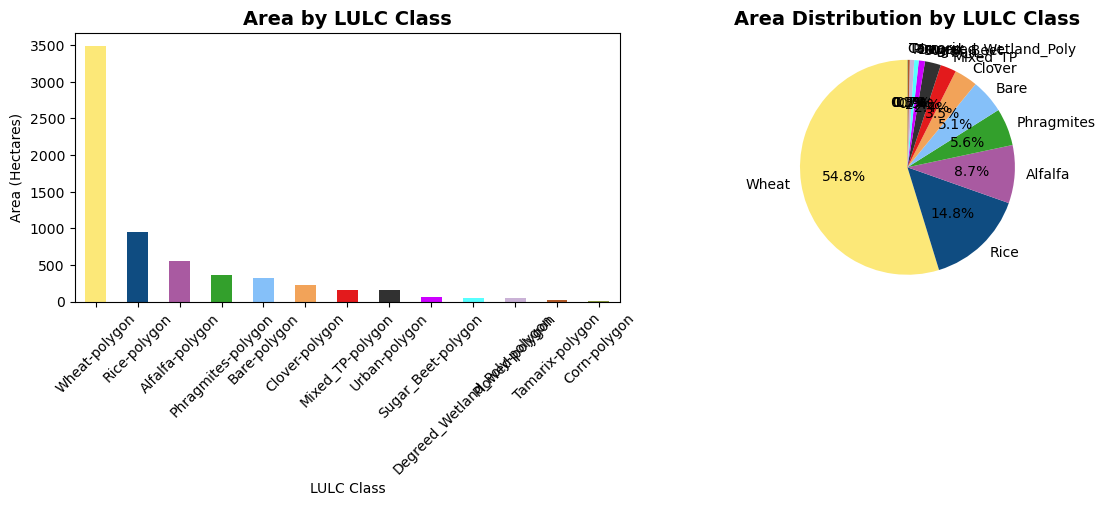


2. CREATING LULC AND CONFIDENCE MAPS
Unique classes found: ['Alfalfa-polygon', 'Bare-polygon', 'Clover-polygon', 'Corn-polygon', 'Degreed_Wetland_Poly-polygon', 'Mixed_TP-polygon', 'Phragmites-polygon', 'Plowed-polygon', 'Rice-polygon', 'Sugar_Beet-polygon', 'Tamarix-polygon', 'Urban-polygon', 'Wheat-polygon']
LULC and confidence maps saved to: F:\_____My_Thesies____\Implimantation\3.Train_Model\4.AugModel_On_No_F-E_Data\__Predict\Predictions_2019_Enhanced_Seasonal\lulc_and_confidence_maps.png


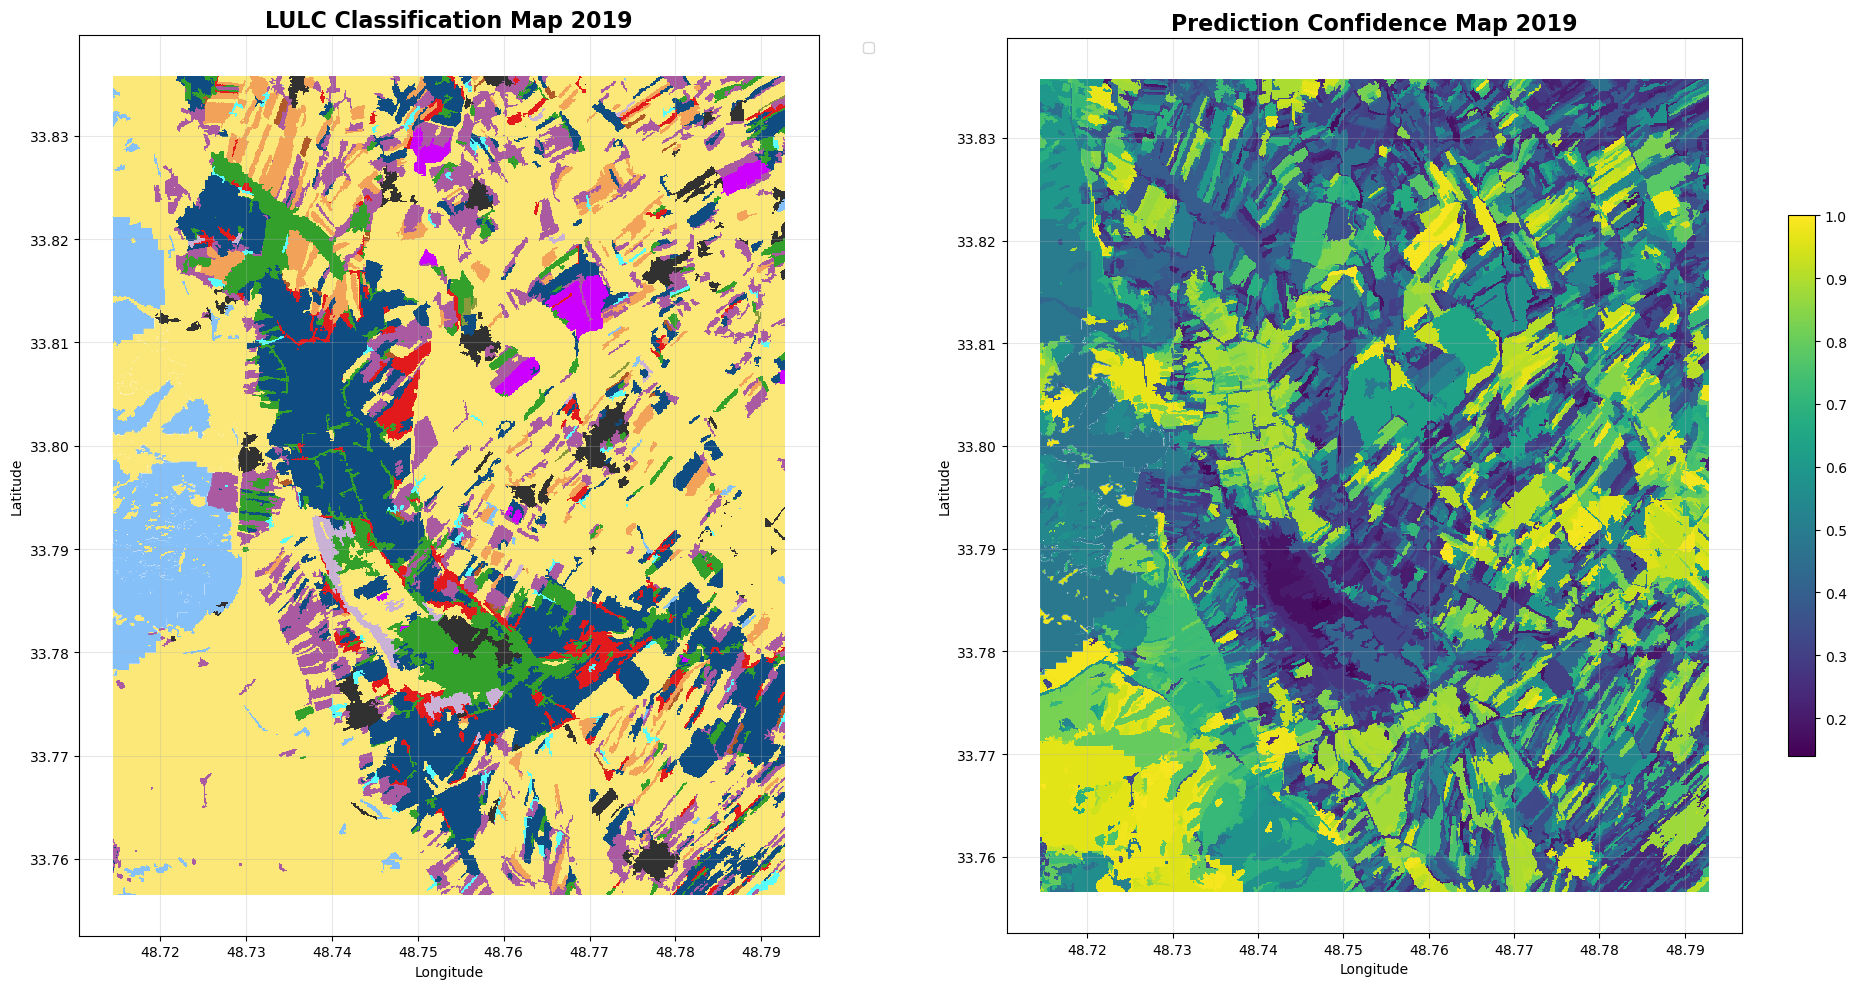

Detailed LULC map saved to: F:\_____My_Thesies____\Implimantation\3.Train_Model\4.AugModel_On_No_F-E_Data\__Predict\Predictions_2019_Enhanced_Seasonal\lulc_map_detailed.png


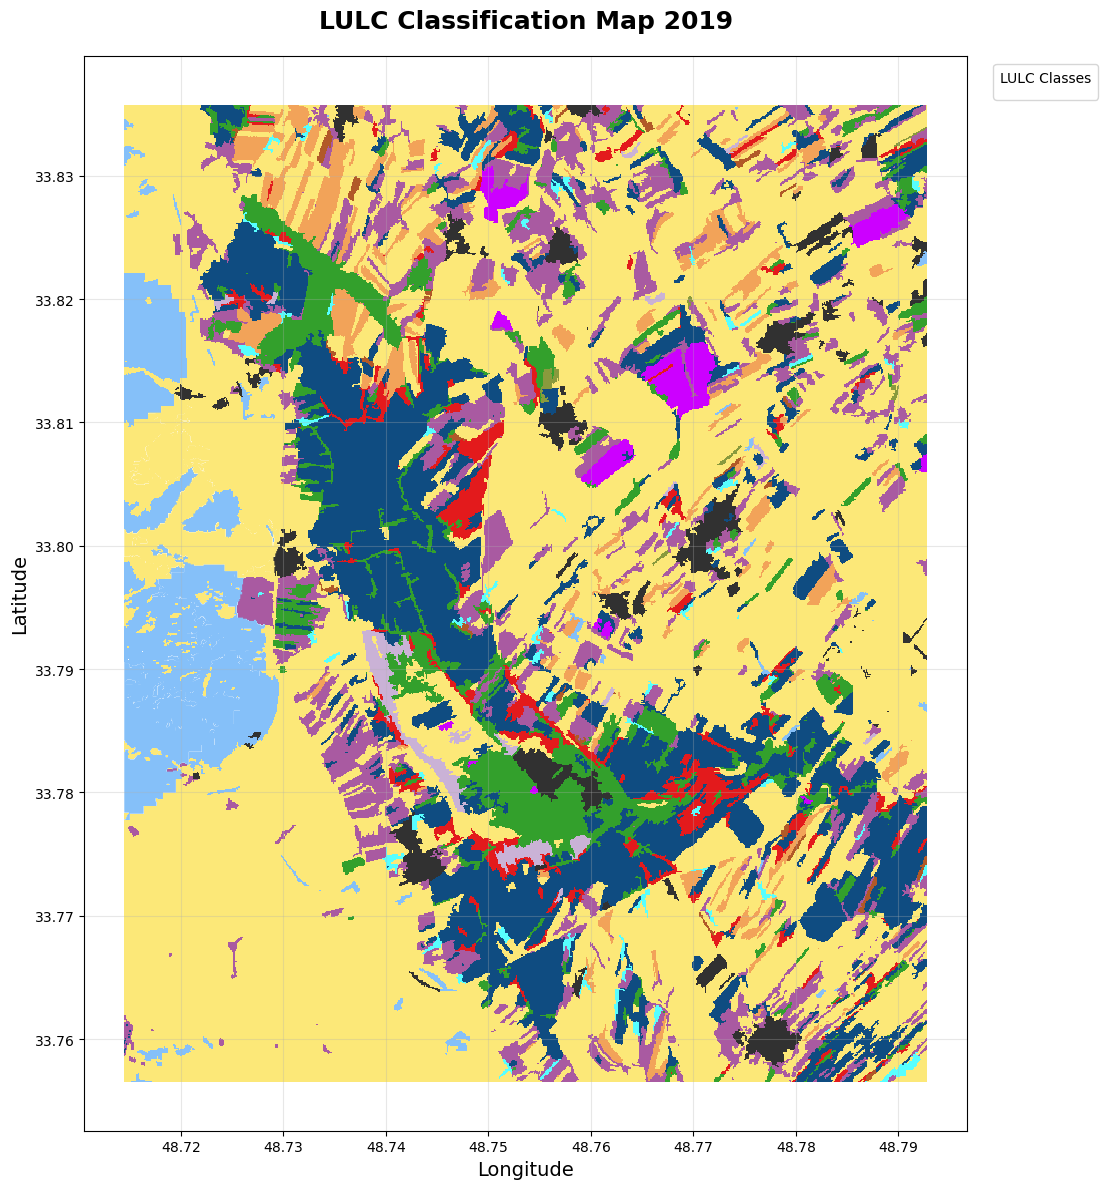


3. SAVING PROCESSED DATA


FieldError: Error adding field 'GLCM_20190205_Mean_mean' to layer

In [12]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# Set up paths
base_path = Path(r"F:\_____My_Thesies____")
predictions_path = base_path / "Implimantation" / "3.Train_Model" / "4.AugModel_On_No_F-E_Data" / "__Predict" / "Predictions_2019_Enhanced_Seasonal" / "predictions_2019.csv"
segmentation_path = base_path / "_ImpFiles" / "3. Feature Selection" / "_Sentinel Data" / "2. Divided Data" / "6.Segmentation" / "Seg_2019" / "segmentation_layer.shp"
output_dir = base_path / "Implimantation" / "3.Train_Model" / "4.AugModel_On_No_F-E_Data" / "__Predict" / "Predictions_2019_Enhanced_Seasonal"

print("Loading data...")
# Load predictions CSV
df_predictions = pd.read_csv(predictions_path)
print(f"Predictions shape: {df_predictions.shape}")
print(f"Predictions columns: {list(df_predictions.columns)}")

# Load segmentation shapefile
gdf_segmentation = gpd.read_file(segmentation_path)
print(f"Segmentation shape: {gdf_segmentation.shape}")
print(f"Segmentation columns: {list(gdf_segmentation.columns)}")

# Check for geometry column in predictions
if 'geometry' in df_predictions.columns:
    print("Found geometry column in predictions")
    # Handle geometry column that contains text strings
    try:
        from shapely import wkt
        from shapely.geometry import Point, Polygon
        
        # Check if geometries are stored as text
        sample_geom = df_predictions['geometry'].dropna().iloc[0] if not df_predictions['geometry'].dropna().empty else None
        
        if sample_geom and isinstance(sample_geom, str):
            print("Geometry stored as text strings, converting to shapely objects...")
            # Convert WKT strings to shapely geometries
            def safe_wkt_loads(geom_str):
                if pd.isna(geom_str) or geom_str == '':
                    return None
                try:
                    return wkt.loads(geom_str)
                except:
                    return None
            
            df_predictions['geometry'] = df_predictions['geometry'].apply(safe_wkt_loads)
        
        # Now create GeoDataFrame
        gdf_predictions = gpd.GeoDataFrame(df_predictions, geometry='geometry')
        # Check for missing geometries
        missing_geom = gdf_predictions['geometry'].isna().sum()
        print(f"Missing geometries after processing: {missing_geom}")
        
    except Exception as e:
        print(f"Error processing geometry column: {e}")
        print("Treating as regular DataFrame")
        gdf_predictions = df_predictions.copy()
        missing_geom = df_predictions['geometry'].isna().sum() if 'geometry' in df_predictions.columns else len(df_predictions)
else:
    print("No geometry column found in predictions")
    gdf_predictions = df_predictions.copy()
    missing_geom = len(df_predictions)

# Merge with segmentation data to fill missing geometries
print("Merging with segmentation data...")
if 'PXLVAL' in df_predictions.columns and 'PXLVAL' in gdf_segmentation.columns:
    # Merge based on PXLVAL
    gdf_merged = gdf_predictions.merge(
        gdf_segmentation[['PXLVAL', 'geometry']], 
        on='PXLVAL', 
        how='left', 
        suffixes=('', '_seg')
    )
    
    # Fill missing geometries
    if 'geometry' in gdf_merged.columns and 'geometry_seg' in gdf_merged.columns:
        # Fill NaN geometries with segmentation geometries
        mask = gdf_merged['geometry'].isna()
        gdf_merged.loc[mask, 'geometry'] = gdf_merged.loc[mask, 'geometry_seg']
        gdf_merged = gdf_merged.drop('geometry_seg', axis=1)
    elif 'geometry_seg' in gdf_merged.columns:
        gdf_merged['geometry'] = gdf_merged['geometry_seg']
        gdf_merged = gdf_merged.drop('geometry_seg', axis=1)
    
    # Convert to GeoDataFrame properly
    try:
        gdf_final = gpd.GeoDataFrame(gdf_merged, geometry='geometry', crs=gdf_segmentation.crs)
        print(f"Final merged data shape: {gdf_final.shape}")
        final_missing_geom = gdf_final['geometry'].isna().sum()
        print(f"Remaining missing geometries: {final_missing_geom}")
    except Exception as e:
        print(f"Error creating final GeoDataFrame: {e}")
        # Fall back to original predictions
        gdf_final = gdf_predictions.copy()
    
else:
    print("PXLVAL column not found, using predictions as is")
    gdf_final = gdf_predictions.copy()

# Identify prediction and confidence columns
pred_cols = [col for col in gdf_final.columns if 'pred' in col.lower() or 'class' in col.lower()]
conf_cols = [col for col in gdf_final.columns if 'conf' in col.lower() or 'prob' in col.lower()]

if not pred_cols:
    # Try to identify the most likely prediction column
    numeric_cols = gdf_final.select_dtypes(include=[np.number]).columns
    pred_cols = [col for col in numeric_cols if col not in ['PXLVAL', 'geometry']]
    if pred_cols:
        pred_col = pred_cols[0]
        print(f"Using {pred_col} as prediction column")
    else:
        print("Could not identify prediction column")
        pred_col = None
else:
    pred_col = pred_cols[0]
    print(f"Using {pred_col} as prediction column")

if not conf_cols and len(pred_cols) > 1:
    conf_col = pred_cols[1]
    print(f"Using {conf_col} as confidence column")
elif conf_cols:
    conf_col = conf_cols[0]
    print(f"Using {conf_col} as confidence column")
else:
    conf_col = None
    print("No confidence column identified")

# Custom color palette
custom_palette = {
    'Wheat-polygon': "#fce878",  
    'Rice-polygon': '#0f4c81',   
    'Alfalfa-polygon': '#a95aa1',
    'Bare-polygon': '#85c0f9',   
    'Phragmites-polygon': '#33a02c', 
    'Urban-polygon': "#313131",     
    'Clover-polygon': '#f2a359',    
    'Mixed_TP-polygon': '#e31a1c',  
    'Degreed_Wetland_Poly-polygon': "#57ffff", 
    'Tamarix-polygon': '#b15928',              
    'Corn-polygon': "#899a3d",                  
    'Sugar_Beet-polygon': "#cc00ff",            
    'Plowed-polygon': '#cab2d6',                
}

# 1. Calculate area of each class
print("\n" + "="*50)
print("1. CALCULATING AREA OF EACH CLASS")
print("="*50)

if pred_col and 'geometry' in gdf_final.columns:
    # Check and transform CRS if needed for area calculations
    print(f"Original CRS: {gdf_final.crs}")
    
    # If CRS is geographic (lat/lon), transform to a suitable projected CRS
    if gdf_final.crs and gdf_final.crs.is_geographic:
        print("Converting from geographic to projected CRS for area calculation...")
        # Use UTM zone for Iran (approximately UTM zone 39N for your coordinates)
        gdf_final_proj = gdf_final.to_crs('EPSG:32639')  # UTM Zone 39N
        print(f"Projected CRS: {gdf_final_proj.crs}")
        area_gdf = gdf_final_proj
    else:
        area_gdf = gdf_final
    
    # Calculate area for each polygon
    area_gdf_clean = area_gdf.dropna(subset=[pred_col, 'geometry']).copy()
    area_gdf_clean['area_m2'] = area_gdf_clean.geometry.area
    area_gdf_clean['area_ha'] = area_gdf_clean['area_m2'] / 10000  # Convert to hectares
    
    # Group by class and sum areas
    class_areas = area_gdf_clean.groupby(pred_col)['area_ha'].sum().sort_values(ascending=False)
    
    print("Class Areas (Hectares):")
    print("-" * 30)
    total_area = 0
    for class_val, area in class_areas.items():
        print(f"Class {class_val}: {area:.2f} ha")
        total_area += area
    print(f"\nTotal Area: {total_area:.2f} ha")
    
    # Save class areas to CSV
    class_areas_df = pd.DataFrame({
        'Class': class_areas.index,
        'Area_Hectares': class_areas.values,
        'Percentage': (class_areas.values / class_areas.sum() * 100)
    })
    
    class_areas_path = output_dir / "class_areas_summary.csv"
    class_areas_df.to_csv(class_areas_path, index=False)
    print(f"\nClass areas saved to: {class_areas_path}")
    
    # Add area columns back to main dataframe
    gdf_final['area_m2'] = area_gdf['area_m2'] if 'area_m2' in area_gdf.columns else None
    gdf_final['area_ha'] = area_gdf['area_ha'] if 'area_ha' in area_gdf.columns else None
    
    # Create area visualization
    plt.figure(figsize=(12, 8))
    
    plt.subplot(2, 2, 1)
    bars = class_areas.plot(kind='bar', color=[custom_palette.get(cls, 'gray') for cls in class_areas.index])
    plt.title('Area by LULC Class', fontsize=14, fontweight='bold')
    plt.xlabel('LULC Class')
    plt.ylabel('Area (Hectares)')
    plt.xticks(rotation=45)
    
    plt.subplot(2, 2, 2)
    colors_for_pie = [custom_palette.get(cls, 'gray') for cls in class_areas.index]
    plt.pie(class_areas.values, labels=[cls.replace('-polygon', '') for cls in class_areas.index], 
            autopct='%1.1f%%', startangle=90, colors=colors_for_pie)
    plt.title('Area Distribution by LULC Class', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    area_plot_path = output_dir / "class_areas_visualization.png"
    plt.savefig(area_plot_path, dpi=300, bbox_inches='tight')
    print(f"Area visualization saved to: {area_plot_path}")
    plt.show()
    
else:
    print("Cannot calculate areas - missing geometry or prediction column")

# 2. Create LULC map and confidence map
print("\n" + "="*50)
print("2. CREATING LULC AND CONFIDENCE MAPS")
print("="*50)

if 'geometry' in gdf_final.columns and pred_col:
    # Clean data for plotting (remove NaN predictions)
    gdf_plot = gdf_final.dropna(subset=[pred_col]).copy()
    
    # Create subplot figure
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # Get unique classes (handle mixed types safely)
    unique_classes = gdf_plot[pred_col].dropna().unique()
    unique_classes = [str(x) for x in unique_classes if pd.notna(x)]
    unique_classes = sorted(unique_classes)
    
    print(f"Unique classes found: {unique_classes}")
    
    # Create color mapping using custom palette
    color_map = {}
    for cls in unique_classes:
        if cls in custom_palette:
            color_map[cls] = custom_palette[cls]
        else:
            # Fallback color for classes not in palette
            color_map[cls] = '#808080'  # Gray
    
    # Plot 1: LULC Map
    ax1 = axes[0]
    
    # Plot each class separately to control colors
    for cls in unique_classes:
        class_data = gdf_plot[gdf_plot[pred_col] == cls]
        if not class_data.empty:
            class_data.plot(ax=ax1, color=color_map[cls], label=cls.replace('-polygon', ''))
    
    ax1.set_title('LULC Classification Map 2019', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    
    # Plot 2: Confidence Map
    ax2 = axes[1]
    if conf_col and conf_col in gdf_plot.columns:
        # Clean confidence data
        conf_data = gdf_plot.dropna(subset=[conf_col])
        if not conf_data.empty:
            im = conf_data.plot(column=conf_col, ax=ax2, cmap='viridis', 
                               legend=True, legend_kwds={'shrink': 0.6})
            ax2.set_title('Prediction Confidence Map 2019', fontsize=16, fontweight='bold')
        else:
            ax2.text(0.5, 0.5, 'No valid confidence data', ha='center', va='center', transform=ax2.transAxes)
            ax2.set_title('No Confidence Data Available', fontsize=16, fontweight='bold')
    else:
        # If no confidence column, create a dummy confidence based on class frequency
        class_counts = gdf_plot[pred_col].value_counts()
        gdf_plot['dummy_confidence'] = gdf_plot[pred_col].map(
            lambda x: class_counts[x] / len(gdf_plot)
        )
        gdf_plot.plot(column='dummy_confidence', ax=ax2, cmap='viridis', 
                      legend=True, legend_kwds={'shrink': 0.6})
        ax2.set_title('Relative Class Frequency Map 2019', fontsize=16, fontweight='bold')
    
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save the map
    map_path = output_dir / "lulc_and_confidence_maps.png"
    plt.savefig(map_path, dpi=300, bbox_inches='tight')
    print(f"LULC and confidence maps saved to: {map_path}")
    plt.show()
    
    # Create individual high-resolution LULC map
    fig, ax = plt.subplots(1, 1, figsize=(15, 12))
    
    # Plot each class separately with custom colors
    for cls in unique_classes:
        class_data = gdf_plot[gdf_plot[pred_col] == cls]
        if not class_data.empty:
            class_data.plot(ax=ax, color=color_map[cls], label=cls.replace('-polygon', ''))
    
    ax.set_title('LULC Classification Map 2019', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Longitude', fontsize=14)
    ax.set_ylabel('Latitude', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # Add legend
    ax.legend(title='LULC Classes', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=12)
    
    plt.tight_layout()
    lulc_map_path = output_dir / "lulc_map_detailed.png"
    plt.savefig(lulc_map_path, dpi=300, bbox_inches='tight')
    print(f"Detailed LULC map saved to: {lulc_map_path}")
    plt.show()

else:
    print("Cannot create maps - missing geometry or prediction column")

# Save processed data
print("\n" + "="*50)
print("3. SAVING PROCESSED DATA")
print("="*50)

# Save the final GeoDataFrame
if 'geometry' in gdf_final.columns:
    processed_shp_path = output_dir / "predictions_2019_with_geometry.shp"
    gdf_final.to_file(processed_shp_path)
    print(f"Processed data with geometry saved to: {processed_shp_path}")

# Save as CSV
processed_csv_path = output_dir / "predictions_2019_processed.csv"
# Remove geometry column for CSV if it exists
df_for_csv = gdf_final.drop('geometry', axis=1) if 'geometry' in gdf_final.columns else gdf_final
df_for_csv.to_csv(processed_csv_path, index=False)
print(f"Processed data (CSV) saved to: {processed_csv_path}")

# Create summary statistics
print("\n" + "="*50)
print("4. SUMMARY STATISTICS")
print("="*50)

summary_stats = {}
if pred_col:
    summary_stats['Total_Segments'] = len(gdf_final)
    summary_stats['Unique_Classes'] = gdf_final[pred_col].nunique()
    summary_stats['Class_Distribution'] = gdf_final[pred_col].value_counts().to_dict()
    
    if 'area_ha' in gdf_final.columns:
        summary_stats['Total_Area_Ha'] = gdf_final['area_ha'].sum()
        summary_stats['Average_Segment_Area_Ha'] = gdf_final['area_ha'].mean()
    
    if conf_col:
        summary_stats['Average_Confidence'] = gdf_final[conf_col].mean()
        summary_stats['Min_Confidence'] = gdf_final[conf_col].min()
        summary_stats['Max_Confidence'] = gdf_final[conf_col].max()

# Save summary to JSON
import json
summary_path = output_dir / "analysis_summary.json"
with open(summary_path, 'w') as f:
    json.dump(summary_stats, f, indent=2, default=str)

print(f"Summary statistics saved to: {summary_path}")

print("\n" + "="*50)
print("ANALYSIS COMPLETE!")
print("="*50)
print(f"All results saved to: {output_dir}")
print("\nFiles created:")
print("- class_areas_summary.csv")
print("- class_areas_visualization.png")
print("- lulc_and_confidence_maps.png")
print("- lulc_map_detailed.png")
print("- predictions_2019_with_geometry.shp")
print("- predictions_2019_processed.csv")
print("- analysis_summary.json")